Here we will see how we can make use of our saved coordinates
With the map, we will want to apply two filter: price and price per square feet

In [1]:
import folium
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('database.csv')
df.head()

,ID,PRICE,SIZE,ROOMS,DATE,OWNER,LAT,LON
0,67837996,549000,45.62,2,29.04.2026,prywatny,50.656732,17.897874
1,67953693,710000,60.00,3,28.04.2026,prywatny,50.666950,17.937210
2,67954267,639000,64.12,3,28.04.2026,biuro nieruchomości,50.664387,17.933162
3,67926507,460000,46.61,3,28.04.2026,biuro nieruchomości,50.662900,17.897750
4,67686199,779000,75.61,4,28.04.2026,biuro nieruchomości,50.650100,17.854300


In [ ]:
# center map
m = folium.Map(location=[df["LAT"].mean(), df["LON"].mean()],
               zoom_start=6)

# add markers
for _, row in df.iterrows():
    folium.Marker(
        [row["LAT"], row["LON"]],
        popup=row["ID"]
    ).add_to(m)

# save map
m.save("map.html")

<Axes: >

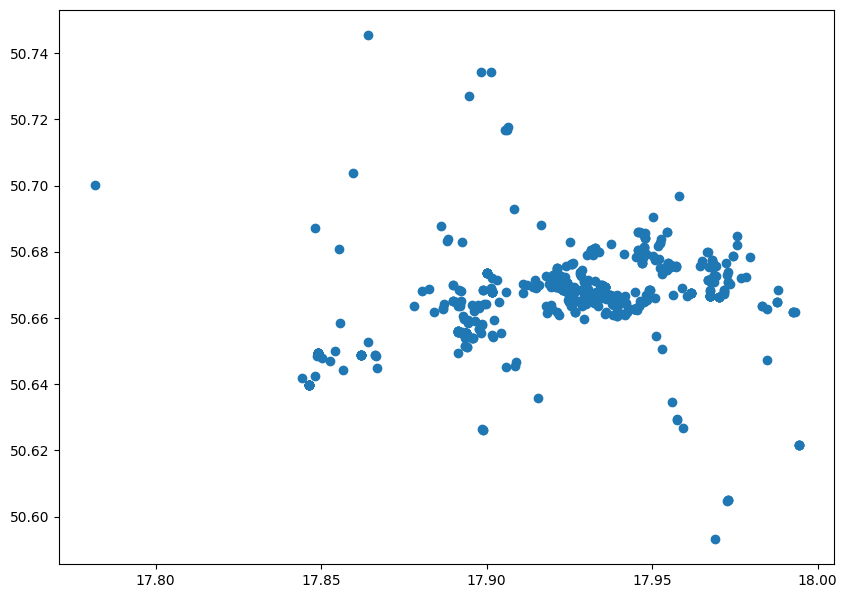

In [4]:
import geopandas as gpd
from shapely.geometry import Point

geometry = [
    Point(xy) for xy in zip(df["LON"], df["LAT"])
]

gdf = gpd.GeoDataFrame(df, geometry=geometry)

gdf.plot(figsize=(10, 10))

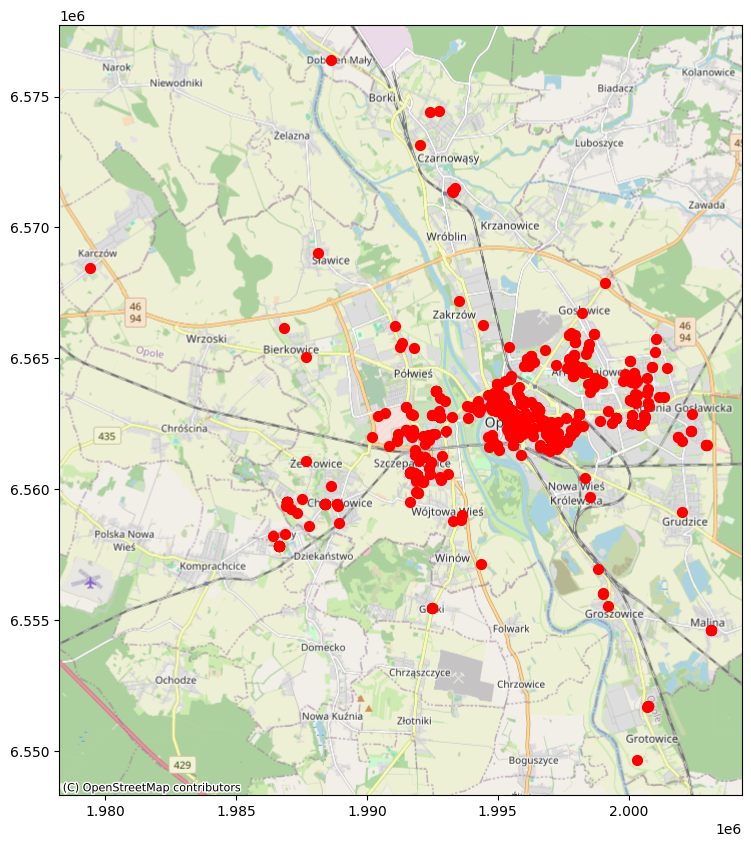

In [5]:
import contextily as ctx

# Create geometry column
geometry = [
    Point(xy) for xy in zip(df["LON"], df["LAT"])
]

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"   # GPS coordinates
)

# Convert to web mercator for web tiles
gdf_web = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

gdf_web.plot(
    ax=ax,
    color="red",
    markersize=50
)

# Add basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

plt.show()